In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import sqlalchemy

In [171]:
transacoes = pd.read_csv("data/transacoes.csv", sep=';')

In [172]:
produtos = pd.read_csv("data/produtos.csv", sep=';')

In [173]:
clientes = pd.read_csv("data/clientes.csv", sep=';')

In [174]:
clientes.head()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2,2025-11-13 12:03:56.114,2025-12-13 11:45:37.364
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100,2025-10-29 02:08:18.367,2026-02-24 04:49:02.551


In [175]:
clientes.to_json("clientes.json", index=False)

### Copiando os dados do Control + C -> Control + V (arquivo bobo.csv)

In [176]:
# df = pd.read_clipboard(sep=',')

### Usando arquivos de páginas HTML

In [177]:
# url = "https://pt.wikipedia.org/wiki/Unidades_federativas_do_Brasil"
# estados = pd.read_html(url)
# estados

In [178]:
url = "https://pt.wikipedia.org/wiki/Unidades_federativas_do_Brasil"

# Definindo um cabeçalho que simula o Chrome
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Lendo as tabelas da página
tabelas = pd.read_html(url, storage_options=headers)

# Geralmente a tabela dos estados é a primeira ou segunda
df_estados = tabelas[1] 
print(df_estados.head())

   Bandeira Unidade federativa Abreviação Sede de governo   Área (km²)  \
0       NaN               Acre         AC      Rio Branco    164 122,2   
1       NaN            Alagoas         AL          Maceió     27 767,7   
2       NaN              Amapá         AP          Macapá    142 814,6   
3       NaN           Amazonas         AM          Manaus  1 570 745,7   
4       NaN              Bahia         BA        Salvador    564 692,7   

  População (Censo 2022)  Densidade (2005)   PIB (2015)  (% total) (2015)  \
0                830 018               430   13 622 000                 2   
1              3 127 683             10861   46 364 000                 8   
2                733 759               416   13 861 000                 2   
3              3 941 613               205   86 560 000                14   
4             14 141 626              2446  245 025 000                41   

  PIB per capita (R$) (2015)  IDH (2010) Alfabetização (2016)  \
0                  16 953,4

## Primeiras linhas

In [179]:
clientes.head(10)

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2,2025-11-13 12:03:56.114,2025-12-13 11:45:37.364
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100,2025-10-29 02:08:18.367,2026-02-24 04:49:02.551
5,002970bd-65c2-42bf-a17d-2bc5e95e2f0b,0,1,0,0,0,0,2025-07-16 09:36:45.831,2025-07-16 09:36:45.831
6,0033b737-8235-4c0f-9801-dc4ca185af00,0,1,0,0,0,2561,2025-02-19 12:48:24.632,2025-08-04 12:06:09.677
7,00417bdf-844f-40bf-92e1-d663373cbbd2,0,1,0,0,0,0,2025-11-10 03:14:09.875,2025-11-10 03:14:09.875
8,00684343-40b5-4ce7-b2e8-71a5340973bf,0,0,0,0,0,0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
9,0068860b-c7eb-4312-830d-4ab9273c9b15,0,1,0,0,0,152,2025-09-29 13:28:20.255,2025-10-13 12:45:50.785


## Últimas linhas

In [180]:
clientes.tail()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
5092,ff2cabd3-3316-4b3f-8494-c25f95e90524,0,1,0,0,0,57,2025-02-10 11:12:30.631,2025-02-10 12:37:47.892
5093,ff4909ad-4e52-4767-a6fc-0fbd76e37857,0,0,0,0,0,50,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
5094,ff5d2399-6b53-49f0-b41e-fdaaa0da172a,0,1,0,0,0,2021,2025-08-25 13:09:12.556,2026-01-30 14:43:50.139
5095,ff8d55dc-64fa-40de-992a-04a4155f5634,0,1,0,0,0,0,2025-07-12 13:50:37.959,2025-07-12 13:50:37.959
5096,fff7862d-4b2c-4140-a4c5-509b48ed31b4,0,1,0,0,0,1000,2025-11-12 01:01:58.698,2025-11-12 01:02:16.561


## Uma amostra aleatória

In [181]:
clientes.sample(5)

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
4203,d11987b7-dc56-4369-a8ef-f12e01c42370,0,1,0,0,0,423,2025-01-28 11:47:22.534,2026-02-03 12:07:53.929
3897,c29ca579-8aed-4bac-987b-e19cc1a1da2a,0,1,0,0,0,4,2025-02-25 11:57:32.624,2025-02-25 12:03:25.655
4282,d5278e80-eb4a-41d4-977b-d5d1ec87f0a9,0,0,0,0,0,53,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
116,052e957b-8569-4932-9b89-ff25f944a094,0,1,0,0,0,219,2025-01-27 12:38:40.933,2025-01-29 12:54:23.820
2493,7c8470d1-048a-4fa6-b61b-3a5a409e4bd0,0,1,0,0,0,534,2025-01-30 13:03:05.536,2025-03-07 13:03:59.734


## Atributo **shape** para determinar linhas e colunas

In [182]:
clientes.shape

(5097, 9)

## Mostrar a lista de colunas

In [183]:
clientes.columns

Index(['idCliente', 'flEmail', 'flTwitch', 'flYouTube', 'flBlueSky',
       'flInstagram', 'qtdePontos', 'DtCriacao', 'DtAtualizacao'],
      dtype='str')

## Mostrar os índices. Caso não existe, o pandas cria um índice sequencial

In [184]:
clientes.index

RangeIndex(start=0, stop=5097, step=1)

## Informações gerais

In [185]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 5097 entries, 0 to 5096
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   idCliente      5097 non-null   str  
 1   flEmail        5097 non-null   int64
 2   flTwitch       5097 non-null   int64
 3   flYouTube      5097 non-null   int64
 4   flBlueSky      5097 non-null   int64
 5   flInstagram    5097 non-null   int64
 6   qtdePontos     5097 non-null   int64
 7   DtCriacao      5097 non-null   str  
 8   DtAtualizacao  5097 non-null   str  
dtypes: int64(6), str(3)
memory usage: 766.7 KB


O valor de memória alocada é uma estimativa (inferência) determinada pelos tipos de dados do Dataframe. para o valor mais preciso, usaremos uma parâmetro memory_usage='deep'

In [186]:
clientes.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 5097 entries, 0 to 5096
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   idCliente      5097 non-null   str  
 1   flEmail        5097 non-null   int64
 2   flTwitch       5097 non-null   int64
 3   flYouTube      5097 non-null   int64
 4   flBlueSky      5097 non-null   int64
 5   flInstagram    5097 non-null   int64
 6   qtdePontos     5097 non-null   int64
 7   DtCriacao      5097 non-null   str  
 8   DtAtualizacao  5097 non-null   str  
dtypes: int64(6), str(3)
memory usage: 766.7 KB


## Detalhamento do tipo das colunas

In [187]:
clientes.dtypes

idCliente          str
flEmail          int64
flTwitch         int64
flYouTube        int64
flBlueSky        int64
flInstagram      int64
qtdePontos       int64
DtCriacao          str
DtAtualizacao      str
dtype: object

In [188]:
type(clientes.dtypes)

pandas.Series

Esse atributo retorna uma série com o tipo preciso de cada coluna. Assim, para verificar um tipo específico de uma coluna.

In [189]:
clientes.dtypes['flEmail']

dtype('int64')

## Renomeando colunas

In [190]:
transacoes.shape

(303154, 5)

In [191]:
transacoes.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 303154 entries, 0 to 303153
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   IdTransacao        303154 non-null  str  
 1   IdCliente          303154 non-null  str  
 2   DtCriacao          303154 non-null  str  
 3   QtdePontos         303154 non-null  int64
 4   DescSistemaOrigem  303154 non-null  str  
dtypes: int64(1), str(4)
memory usage: 40.8 MB


In [192]:
transacoes.dtypes

IdTransacao            str
IdCliente              str
DtCriacao              str
QtdePontos           int64
DescSistemaOrigem      str
dtype: object

Para renomear uma coluna deve ser passado um dicionário: a chave o nome antigo, e o valor com o nome novo.

In [193]:
transacoes.rename(columns={'QtdePontos': 'qtPontos'})

,IdTransacao,IdCliente,DtCriacao,qtPontos,DescSistemaOrigem
0,0000520a-a4e5-4977-b360-17be62fa0f2b,24782f0b-4683-4f35-976a-ea21d6714ba6,2025-09-17 12:28:41.864,1,twitch
1,000060e8-aa76-4286-a8d7-f30e6fa47edd,252a0923-3f79-45bb-b664-3040235c6c58,2024-07-23 12:49:49.874,1,twitch
2,000095de-3daa-4cfb-a0ae-e7b2c8bc3c9b,30f45a6d-ada5-4a17-8338-710e414eb6c6,2025-09-17 13:38:57.479,1,twitch
3,0000c010-a592-46f7-8b0b-6f841bee64ba,65662aff-44d6-4f06-b9d9-07445c6e5943,2025-10-03 12:23:39.779,1,twitch
4,0000dfbb-e14e-4ea7-a57f-60236869fffe,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-20 13:21:45.613,1,twitch
...,...,...,...,...,...
303149,ffff45c7-83dc-4fa9-82b5-b41352093596,6313ceac-7806-4d34-aedd-476eed7c853a,2025-01-03 12:59:27.229,1,twitch
303150,ffff52de-13fb-4405-a797-fddb5b4a48c5,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-24 12:22:26.313,1,twitch
303151,ffffb5ab-047e-43e4-bab3-ee2d19e9b7db,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,2024-08-16 13:09:42.576,1,twitch
303152,ffffc72e-d882-47f0-b933-cfd92c7e6621,2d3d2dce-d353-4961-ad39-46723efe2100,2024-02-06 11:51:24.788,1,twitch


Essa alteração não reflete diretamente no Dataframe. Isso ocorre porque um novo dataframe é criado em memória com a operação realizada.

In [194]:
transacoes.head()

,IdTransacao,IdCliente,DtCriacao,QtdePontos,DescSistemaOrigem
0,0000520a-a4e5-4977-b360-17be62fa0f2b,24782f0b-4683-4f35-976a-ea21d6714ba6,2025-09-17 12:28:41.864,1,twitch
1,000060e8-aa76-4286-a8d7-f30e6fa47edd,252a0923-3f79-45bb-b664-3040235c6c58,2024-07-23 12:49:49.874,1,twitch
2,000095de-3daa-4cfb-a0ae-e7b2c8bc3c9b,30f45a6d-ada5-4a17-8338-710e414eb6c6,2025-09-17 13:38:57.479,1,twitch
3,0000c010-a592-46f7-8b0b-6f841bee64ba,65662aff-44d6-4f06-b9d9-07445c6e5943,2025-10-03 12:23:39.779,1,twitch
4,0000dfbb-e14e-4ea7-a57f-60236869fffe,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-20 13:21:45.613,1,twitch


Mais de uma alteração

In [195]:
transacoes.rename(columns={'qtPontos':'QtdePontos' ,
                           'DescSistemaOrigem': 'sistemaOrigem'})

,IdTransacao,IdCliente,DtCriacao,QtdePontos,sistemaOrigem
0,0000520a-a4e5-4977-b360-17be62fa0f2b,24782f0b-4683-4f35-976a-ea21d6714ba6,2025-09-17 12:28:41.864,1,twitch
1,000060e8-aa76-4286-a8d7-f30e6fa47edd,252a0923-3f79-45bb-b664-3040235c6c58,2024-07-23 12:49:49.874,1,twitch
2,000095de-3daa-4cfb-a0ae-e7b2c8bc3c9b,30f45a6d-ada5-4a17-8338-710e414eb6c6,2025-09-17 13:38:57.479,1,twitch
3,0000c010-a592-46f7-8b0b-6f841bee64ba,65662aff-44d6-4f06-b9d9-07445c6e5943,2025-10-03 12:23:39.779,1,twitch
4,0000dfbb-e14e-4ea7-a57f-60236869fffe,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-20 13:21:45.613,1,twitch
...,...,...,...,...,...
303149,ffff45c7-83dc-4fa9-82b5-b41352093596,6313ceac-7806-4d34-aedd-476eed7c853a,2025-01-03 12:59:27.229,1,twitch
303150,ffff52de-13fb-4405-a797-fddb5b4a48c5,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-24 12:22:26.313,1,twitch
303151,ffffb5ab-047e-43e4-bab3-ee2d19e9b7db,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,2024-08-16 13:09:42.576,1,twitch
303152,ffffc72e-d882-47f0-b933-cfd92c7e6621,2d3d2dce-d353-4961-ad39-46723efe2100,2024-02-06 11:51:24.788,1,twitch


Se for pensar em legibilidade, se pode criar um dicionário separado e depois passá-lo para a função rename.

In [196]:
colunas_renomeadas = {
    'qtPontos': 'QtdePontos' ,
    'DescSistemaOrigem': 'sistemaOrigem'
}

In [197]:
transacoes.rename(columns=colunas_renomeadas)

,IdTransacao,IdCliente,DtCriacao,QtdePontos,sistemaOrigem
0,0000520a-a4e5-4977-b360-17be62fa0f2b,24782f0b-4683-4f35-976a-ea21d6714ba6,2025-09-17 12:28:41.864,1,twitch
1,000060e8-aa76-4286-a8d7-f30e6fa47edd,252a0923-3f79-45bb-b664-3040235c6c58,2024-07-23 12:49:49.874,1,twitch
2,000095de-3daa-4cfb-a0ae-e7b2c8bc3c9b,30f45a6d-ada5-4a17-8338-710e414eb6c6,2025-09-17 13:38:57.479,1,twitch
3,0000c010-a592-46f7-8b0b-6f841bee64ba,65662aff-44d6-4f06-b9d9-07445c6e5943,2025-10-03 12:23:39.779,1,twitch
4,0000dfbb-e14e-4ea7-a57f-60236869fffe,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-20 13:21:45.613,1,twitch
...,...,...,...,...,...
303149,ffff45c7-83dc-4fa9-82b5-b41352093596,6313ceac-7806-4d34-aedd-476eed7c853a,2025-01-03 12:59:27.229,1,twitch
303150,ffff52de-13fb-4405-a797-fddb5b4a48c5,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-24 12:22:26.313,1,twitch
303151,ffffb5ab-047e-43e4-bab3-ee2d19e9b7db,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,2024-08-16 13:09:42.576,1,twitch
303152,ffffc72e-d882-47f0-b933-cfd92c7e6621,2d3d2dce-d353-4961-ad39-46723efe2100,2024-02-06 11:51:24.788,1,twitch


## Realizando a alteração efetivamente no dataframe

Duas formas pode ser usadas:
- Atribuindo novamente ao mesmo dataframe;
- usando o parâmetro inplace=True


In [198]:
# transacoes = transacoes.rename(columns=colunas_renomeadas, inplace=True)

In [199]:
type(transacoes)

pandas.DataFrame

In [200]:
transacoes.head(2)

,IdTransacao,IdCliente,DtCriacao,QtdePontos,DescSistemaOrigem
0,0000520a-a4e5-4977-b360-17be62fa0f2b,24782f0b-4683-4f35-976a-ea21d6714ba6,2025-09-17 12:28:41.864,1,twitch
1,000060e8-aa76-4286-a8d7-f30e6fa47edd,252a0923-3f79-45bb-b664-3040235c6c58,2024-07-23 12:49:49.874,1,twitch


### Navegação no dataframe

In [201]:
transacoes['IdCliente'].iloc[1:4]

1    252a0923-3f79-45bb-b664-3040235c6c58
2    30f45a6d-ada5-4a17-8338-710e414eb6c6
3    65662aff-44d6-4f06-b9d9-07445c6e5943
Name: IdCliente, dtype: str

Esse comando retorna um Série do dataframe

In [202]:
type(transacoes['IdCliente'].iloc[1:4])

pandas.Series

### Mais de coluna

In [203]:
# transacoes['IdCliente', 'QtdePontos']

Esse erro ocorre porque apenas um valor (objeto) pode ser passado na navegação. Para isso, é usado uma lista

In [204]:
transacoes.columns

Index(['IdTransacao', 'IdCliente', 'DtCriacao', 'QtdePontos',
       'DescSistemaOrigem'],
      dtype='str')

In [205]:
transacoes[['IdCliente', 'QtdePontos']]

,IdCliente,QtdePontos
0,24782f0b-4683-4f35-976a-ea21d6714ba6,1
1,252a0923-3f79-45bb-b664-3040235c6c58,1
2,30f45a6d-ada5-4a17-8338-710e414eb6c6,1
3,65662aff-44d6-4f06-b9d9-07445c6e5943,1
4,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,1
...,...,...
303149,6313ceac-7806-4d34-aedd-476eed7c853a,1
303150,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,1
303151,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,1
303152,2d3d2dce-d353-4961-ad39-46723efe2100,1


Agora diferentemente de comandos anteriores, este último comando não retorna uma série, e sim, um novo dataframe. Ele somente será uma Série, e for passado apenas uma coluna do dataframe.

In [206]:
type(transacoes[['IdCliente', 'QtdePontos']])

pandas.DataFrame

### Mesclando os conceitos

In [207]:
(transacoes[['IdCliente', 'QtdePontos']].sample(10))

,IdCliente,QtdePontos
120903,acc75571-ba57-4cb5-bb7b-c140987ae94d,1
146574,056caf66-d67b-449e-8cba-0bab8aca5949,50
213479,5666b127-f796-4b9b-8b82-25d5fcbca816,1
291658,aa3eaf74-6d9c-4859-b733-5a18a3b2f71b,1
3079,811a2aa0-fca5-44ca-8e9b-a5deea2bd7c4,1
196434,1ae9441a-706b-4e92-b309-18f69812c044,1
189026,45363740-2e94-496a-a0c9-c37f6388ae70,50
70135,2d3d2dce-d353-4961-ad39-46723efe2100,1
195266,1856963a-84cb-453e-a139-eb7d8d9b3255,1
120919,65662aff-44d6-4f06-b9d9-07445c6e5943,1


## Reordenar as colunas

In [208]:
transacoes.sample()

,IdTransacao,IdCliente,DtCriacao,QtdePontos,DescSistemaOrigem
229498,c1d96baf-92e6-4366-be41-5dea228e750c,e7c79c1a-7693-4e63-a844-c755e0bc3bd3,2024-04-08 13:54:50.268,1,twitch


### Apenas para exibição

In [209]:
transacoes[["DescSistemaOrigem","QtdePontos" ,"DtCriacao", "IdCliente"]].sample(7)

,DescSistemaOrigem,QtdePontos,DtCriacao,IdCliente
242230,twitch,1,2024-03-19 13:01:32.278,edc875d5-6b6c-4a37-bf2e-0aaaac396701
96363,twitch,1,2025-12-12 13:43:26.400,451766e5-10d1-41f9-b176-ac3aa34e5a59
85928,twitch,50,2025-06-12 12:00:13.291,2b3c43d9-b054-4d09-b342-336d94dd010e
48815,twitch,1,2025-02-07 11:54:09.894,ca35412d-b340-4e7d-a391-020ec6bb6517
150494,twitch,1,2024-04-20 00:15:17.082,65662aff-44d6-4f06-b9d9-07445c6e5943
132525,twitch,1,2024-02-27 12:29:42.586,c82effb8-3951-4752-b834-d42175dcae8b
283242,twitch,1,2025-10-03 13:58:29.203,b31838a9-6ad2-454c-af22-0ecd9e66b298


In [210]:
listas_colunas = transacoes.columns.to_list()

In [211]:
listas_colunas.sort()

In [212]:
transacoes = transacoes[listas_colunas]

# Aplicando Filtros

In [213]:
transacoes['QtdePontos'] >= 50

0         False
1         False
2         False
3         False
4         False
          ...  
303149    False
303150    False
303151    False
303152    False
303153    False
Name: QtdePontos, Length: 303154, dtype: bool

In [214]:
type(transacoes['QtdePontos'] >= 50)

pandas.Series

In [215]:
filtro = transacoes['QtdePontos'] >= 50
transacoes[filtro]

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
12,twitch,2024-11-11 12:36:33.625,9d023e72-c799-40c0-907a-96e023a97959,00028d36-4575-4d02-b2a0-bdae1bc83231,50
21,twitch,2025-11-25 12:13:19.266,1b08989c-039d-4c82-879b-0f56159a1ebb,0003acb0-624a-4e65-bf95-426450b4434d,50
28,twitch,2025-07-16 12:05:28.007,f5719706-915b-4bb1-b9be-c4acb3bd7837,0005855d-2c33-4bfd-85fe-2c7ffaf73151,50
32,twitch,2025-01-09 12:29:28.501,3f55b86f-dc21-4ac8-8e89-7c1535359eaf,00068e23-5b1e-432a-83df-8a5d11e495a6,50
37,twitch,2024-08-12 14:27:40.420,aaad5474-eb6b-4da6-9755-a1d2541c42bd,00079f55-6df7-45c9-ac84-e4adb788563a,50
...,...,...,...,...,...
303122,twitch,2024-04-16 12:48:10.581,a4b70d73-1938-4f27-b1e5-973526894b10,fff97b21-63f3-4289-afe8-e672b1306296,50
303132,twitch,2024-02-29 12:35:20.673,9aba2685-7c0a-4d1f-8e22-0c47ca0af580,fffb4d1f-5197-470f-936e-f7289bc5c878,50
303135,twitch,2024-07-04 12:53:21.075,ca35412d-b340-4e7d-a391-020ec6bb6517,fffba02b-d70c-4bfc-aa51-a4b66b442d53,50
303139,twitch,2025-10-02 11:56:38.812,1dd4b8bc-f909-42bf-9748-88decb919c94,fffd0631-ac87-4432-bf7d-b7200fda8f0c,50


### Mesclando o conhecimentos

In [216]:
transacoes[transacoes['QtdePontos'] <= 50].sample(4)

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
40076,twitch,2024-04-20 00:06:26.539,b4a6af04-57ab-4c65-8525-699e249c50b6,21b95b11-a62e-4df3-b4f1-88feeeca973e,1
131728,twitch,2024-02-05 12:24:43.730,9c909d1e-fa2a-47b0-8535-d9e44375f9f8,6f88ca02-8840-4516-aaac-ecd51399fdbf,1
188577,twitch,2024-04-23 19:43:20.955,ed034cb1-ea7e-4e22-9221-dd069037a701,9f4b2fc3-83e8-4195-b095-b80eaba63e42,1
193105,twitch,2025-10-17 12:41:58.868,909c837a-9b67-4378-901b-53626c6aafd4,a323be2f-3f2d-4fe5-bd9d-be381be891dc,50


É possível fazer com uma lista. Isso somente é possível por que o filtro tem a mesma dimensão do dataframe.

In [217]:
filtro = filtro.tolist()
transacoes[filtro]

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
12,twitch,2024-11-11 12:36:33.625,9d023e72-c799-40c0-907a-96e023a97959,00028d36-4575-4d02-b2a0-bdae1bc83231,50
21,twitch,2025-11-25 12:13:19.266,1b08989c-039d-4c82-879b-0f56159a1ebb,0003acb0-624a-4e65-bf95-426450b4434d,50
28,twitch,2025-07-16 12:05:28.007,f5719706-915b-4bb1-b9be-c4acb3bd7837,0005855d-2c33-4bfd-85fe-2c7ffaf73151,50
32,twitch,2025-01-09 12:29:28.501,3f55b86f-dc21-4ac8-8e89-7c1535359eaf,00068e23-5b1e-432a-83df-8a5d11e495a6,50
37,twitch,2024-08-12 14:27:40.420,aaad5474-eb6b-4da6-9755-a1d2541c42bd,00079f55-6df7-45c9-ac84-e4adb788563a,50
...,...,...,...,...,...
303122,twitch,2024-04-16 12:48:10.581,a4b70d73-1938-4f27-b1e5-973526894b10,fff97b21-63f3-4289-afe8-e672b1306296,50
303132,twitch,2024-02-29 12:35:20.673,9aba2685-7c0a-4d1f-8e22-0c47ca0af580,fffb4d1f-5197-470f-936e-f7289bc5c878,50
303135,twitch,2024-07-04 12:53:21.075,ca35412d-b340-4e7d-a391-020ec6bb6517,fffba02b-d70c-4bfc-aa51-a4b66b442d53,50
303139,twitch,2025-10-02 11:56:38.812,1dd4b8bc-f909-42bf-9748-88decb919c94,fffd0631-ac87-4432-bf7d-b7200fda8f0c,50


Para provar que dará erro - passar uma quantidade diferente de dimensões.

In [218]:
# filtro_errado = [False, True]
# transacoes[filtro_errado]

### Aplicando intervalos

In [219]:
filtro_intervalo = (transacoes['QtdePontos'] >= 50) & (transacoes['QtdePontos'] < 100)
transacoes[filtro_intervalo].tail()

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
303118,twitch,2025-11-28 12:57:47.633,8b7fa7ca-c541-4c97-b06f-a06b2368a1ea,fff723cb-e360-470d-a531-65d7d0cae718,50
303122,twitch,2024-04-16 12:48:10.581,a4b70d73-1938-4f27-b1e5-973526894b10,fff97b21-63f3-4289-afe8-e672b1306296,50
303132,twitch,2024-02-29 12:35:20.673,9aba2685-7c0a-4d1f-8e22-0c47ca0af580,fffb4d1f-5197-470f-936e-f7289bc5c878,50
303135,twitch,2024-07-04 12:53:21.075,ca35412d-b340-4e7d-a391-020ec6bb6517,fffba02b-d70c-4bfc-aa51-a4b66b442d53,50
303139,twitch,2025-10-02 11:56:38.812,1dd4b8bc-f909-42bf-9748-88decb919c94,fffd0631-ac87-4432-bf7d-b7200fda8f0c,50


In [220]:
transacoes[(transacoes['QtdePontos'] == 1) | (transacoes['QtdePontos'] == 100 )].sample(6)

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
265220,twitch,2025-02-11 11:51:11.402,e7b942c7-19d0-4096-ad1e-a9b8c8aee4a8,e005dabe-483f-4f22-b98e-278a0a2b29a2,1
229987,twitch,2025-10-23 12:08:51.341,450a3f75-9c8a-4eb2-b39c-f718ec24f40c,c2441ab8-6ed1-4825-9469-7354058fd7cb,1
206852,twitch,2024-03-04 12:24:09.030,3f55b86f-dc21-4ac8-8e89-7c1535359eaf,aeb17cd4-36ae-43ae-9c18-c37fb91f292e,1
23264,twitch,2025-08-29 13:57:26.077,6668f338-bf25-45ca-958c-94440f5e078e,1397f990-526f-4813-b220-0c9232c022b1,1
168087,twitch,2024-07-01 13:22:59.447,14c81fcd-9277-4176-82c1-005864cdcdf4,8e2732db-d562-4a87-8e59-eaec8f5f2326,1
267107,twitch,2024-05-03 13:08:29.640,3458efb0-0a7e-490f-8856-c29f9050d938,e19c8d42-1a0f-45b2-a6ac-b0beb9cd310d,1


Na lógica Booleana a multiplicação é AND e a soma será o OR

1 * 0 

In [221]:
transacoes[transacoes['QtdePontos'].isin([5,100,40])]

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
154,twitch,2025-08-06 14:34:33.669,000ff655-fa9f-4baa-a108-47f581ec52a1,0020738d-ac83-4400-9ac3-efb23683ca0d,100
164,twitch,2025-10-17 12:41:36.543,c064fb47-ba0b-4076-b15c-115d243dbecf,0021337d-acc7-468b-bbb4-55bc5795e4cd,100
238,twitch,2024-08-27 12:01:24.968,00a6d4c8-38e5-4e92-981e-4e4ac5084546,00306432-3819-46a7-8fe1-4bccc61121b7,100
387,twitch,2025-12-05 12:17:02.208,a8af0598-1c00-496f-8401-88d62724fed7,0050ccd7-e117-464d-97e7-c03e652118bc,100
430,twitch,2025-03-12 11:41:09.087,4fade907-6e0f-4581-a674-aad6622b1b10,00589e5c-a705-48a0-b705-926fe554e133,100
...,...,...,...,...,...
302683,twitch,2024-07-05 11:52:13.467,1b56823a-1f42-43ef-9295-a587f2eb9e78,ff937aa9-9167-4bfe-a462-78dd8deab88c,100
302722,twitch,2024-03-08 11:56:06.798,4c77c153-19b9-42e2-a03c-04f43dcc6105,ff9d2745-fe0c-40b5-ab18-1aaa161ab558,100
302955,twitch,2024-10-03 11:31:18.565,fcda54f6-b9e9-41cf-b255-0594d9947d1b,ffd2339c-f7f0-42db-bbcb-2c367bbbc8b7,100
303013,twitch,2025-05-30 14:44:18.805,7107771a-0558-4aaa-a66e-570205a7f367,ffe029e1-1f33-430f-a45a-678ece053e2c,100


In [222]:
clientes_pontuacao_zerados = clientes[clientes['qtdePontos'] == 0]

Neste código acima, o dataframe **clientes_pontuacao_zerados** ele aponta a referência para as linhas que se aplicam para filtro. Isso é uma vantagem já que há mais a necessidade de duplicar toda o dataframe. A mesma ideia das listas.

In [223]:
a = [1,2]
b = a

print(a)
print(b)

b.append(3)

print(a)
print(b)

b = a.copy()
b.append(4)

print("Lista A: ", a)
print("Lista B ", b)

[1, 2]
[1, 2]
[1, 2, 3]
[1, 2, 3]
Lista A:  [1, 2, 3]
Lista B  [1, 2, 3, 4]


In [224]:
clientes_pontuacao_zerados

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
5,002970bd-65c2-42bf-a17d-2bc5e95e2f0b,0,1,0,0,0,0,2025-07-16 09:36:45.831,2025-07-16 09:36:45.831
7,00417bdf-844f-40bf-92e1-d663373cbbd2,0,1,0,0,0,0,2025-11-10 03:14:09.875,2025-11-10 03:14:09.875
8,00684343-40b5-4ce7-b2e8-71a5340973bf,0,0,0,0,0,0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
10,007b8e64-a244-4404-8992-3b8098b33ccc,0,1,0,0,0,0,2025-06-10 16:13:43.144,2025-06-10 16:13:43.144
11,00942a67-2ffd-4afe-a10e-3caf6e950e0f,0,1,0,0,0,0,2025-10-20 22:16:31.357,2025-10-20 22:16:31.357
...,...,...,...,...,...,...,...,...,...
5078,fe7cba1d-c594-4776-9f7f-c32aebf2404f,0,1,0,0,0,0,2025-12-07 16:25:09.216,2025-12-07 16:25:09.216
5080,fe830a3f-5dcb-4273-ad43-465aeeb3a460,0,1,0,0,0,0,2025-10-24 17:18:33.447,2025-10-24 17:18:33.447
5082,fea95103-cef1-4bf4-9b72-3af3191e8705,0,1,0,0,0,0,2025-10-31 12:21:28.962,2025-10-31 12:21:28.962
5083,feaf434b-e428-4445-a86e-6218c40d55ae,0,1,0,0,0,0,2025-07-08 05:14:32.687,2025-07-08 05:14:32.687


## Operações com dataframes

Realizando um operação de uma série com um valor escalar

In [225]:
# clientes_pontuacao_zerados['coluna_nova'] + 100

In [226]:
clientes_pontuacao_zerados.sample()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
2886,8ebe168f-d4e3-4aed-ae22-391638af872d,0,1,0,0,0,0,2026-03-03 22:44:15.066,2026-03-03 22:44:15.066


In [227]:
clientes_pontuacao_zerados['coluna_nova'] = 1

In [228]:
clientes_pontuacao_zerados.head(2)

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,coluna_nova
5,002970bd-65c2-42bf-a17d-2bc5e95e2f0b,0,1,0,0,0,0,2025-07-16 09:36:45.831,2025-07-16 09:36:45.831,1
7,00417bdf-844f-40bf-92e1-d663373cbbd2,0,1,0,0,0,0,2025-11-10 03:14:09.875,2025-11-10 03:14:09.875,1


In [229]:
transacoes[transacoes['QtdePontos'] > 100]

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
500,twitch,2025-10-30 13:12:26.669,c52fb72f-b3dc-4650-9182-b08b5ed1420a,0066a807-064f-45a1-b5fc-21a04594d790,500
657,twitch,2024-04-03 13:43:18.498,24782f0b-4683-4f35-976a-ea21d6714ba6,0083ee83-6e14-47b0-adc6-0056279a892a,500
783,twitch,2024-04-03 12:31:15.747,d1527845-5bae-4747-b644-0854beaeeb58,009b4b6e-30d1-43fa-9a37-f8a54c7c22f9,500
820,twitch,2024-10-04 12:36:07.021,02bfd4d9-4dd6-44e5-88b8-2cc08caf3267,00a2f350-b341-4d01-b098-fee4184d7052,500
913,twitch,2024-05-27 13:58:22.229,00a6d4c8-38e5-4e92-981e-4e4ac5084546,00b8aaa0-04ff-4774-bfbf-7960e6e99d17,500
...,...,...,...,...,...
302237,twitch,2024-03-19 12:11:13.864,65662aff-44d6-4f06-b9d9-07445c6e5943,ff36a9ec-1927-435a-a30c-794d2c8afed8,500
302317,twitch,2024-07-23 13:46:39.726,961622c3-3c29-4fa1-88d2-4f408d6d6ebb,ff45758a-a3be-4387-8008-2d470df47f54,200
302801,twitch,2024-05-09 12:33:37.191,dfa4b373-d4d7-41ad-ab95-182bb052f008,ffb06574-a957-4064-9bc1-35f9d0274eee,500
303019,twitch,2024-02-22 13:05:46.014,87040a44-0e04-4cc1-ad91-072d167b11b1,ffe18c85-40b8-43b3-8e3d-464d9e15c500,500


### Realizando operações entre séries diferentes

In [230]:
clientes_pontuacao_zerados['coluna_somada_100'] = clientes_pontuacao_zerados['coluna_nova'] + 100

In [231]:
clientes_pontuacao_zerados.sample()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,coluna_nova,coluna_somada_100
2143,6a7d3662-8ab6-43e2-a194-e7f1a58b996d,0,0,0,0,0,0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,1,101


Operação linha a linha

In [232]:
clientes['quantidade_redes_sociais'] = clientes['flInstagram'] + clientes['flTwitch'] + clientes['flEmail'] + clientes['flBlueSky']  + clientes['flYouTube']


Pelo menos uma rede social.

In [233]:
clientes.sample()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais
2415,788fa8a0-575d-4ca9-91ff-6ce7ab42ea32,0,0,0,0,0,150,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0


### aplicando logaritmo natural nos valores da série

In [234]:
clientes.dtypes

idCliente                     str
flEmail                     int64
flTwitch                    int64
flYouTube                   int64
flBlueSky                   int64
flInstagram                 int64
qtdePontos                  int64
DtCriacao                     str
DtAtualizacao                 str
quantidade_redes_sociais    int64
dtype: object

In [235]:
clientes['pontos_log'] = np.log(clientes['qtdePontos'] + 1)

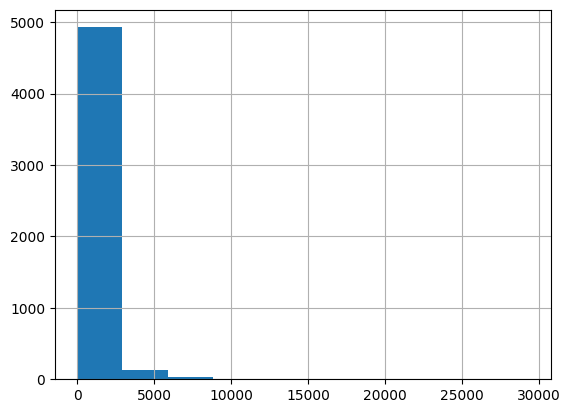

In [236]:
plt.hist(clientes['qtdePontos'])
plt.grid(True)
plt.show()

Distribuição totalmente assimétrica. A ideia de logaritmos natural e justamente deixar menos assimétrica esta distribuição. Ou seja, se tornar mais próximo de uma distribuição normal.

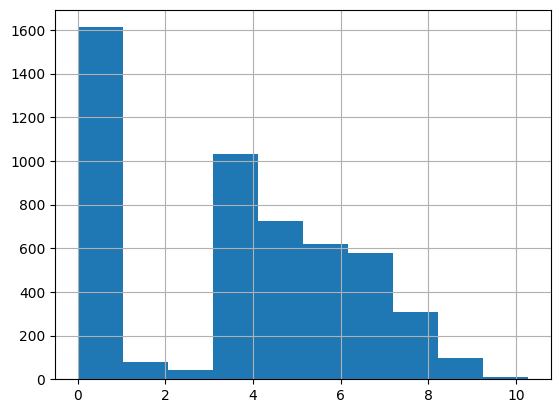

In [237]:
plt.hist(clientes['pontos_log'])
plt.grid(True)
plt.show()

### Ordenação 

O uso da função ***max*** não é útil já que ele enumera apenas um dos maiores valores.

In [238]:
clientes['qtdePontos'].sort_values()

10          0
64          0
5095        0
22          0
17          0
        ...  
2568    16246
4344    22578
881     24096
1       25086
492     29325
Name: qtdePontos, Length: 5097, dtype: int64

Forma mais flexível, ou seja, Esta operação estou ordenando um dataframe, informando por qual a série servirá de referência na ordenação e depois ordenando pelos 5 com mais pontos.

In [239]:
clientes.sort_values(by='qtdePontos', ascending=False).head()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
492,163022e8-12b8-486f-8604-57d8fa0ed7e1,0,1,0,0,0,29325,2025-02-19 13:11:26.517,2026-03-12 13:28:26.203,1,10.286230
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697,0,10.130105
881,2a9d4ba3-4c58-47f9-8dc4-6f9cb50be1b1,1,1,0,0,0,24096,2025-03-07 12:59:11.756,2026-03-12 11:57:35.241,2,10.089843
4344,d7f7eb75-4f0b-4d15-960d-8efe5ca7dd7e,0,0,0,0,0,22578,2025-03-07 12:36:50.254,2026-03-12 12:06:19.192,0,10.024776
2568,803debdb-8136-4cb5-af29-dcd8db36bf2c,0,1,0,0,0,16246,2025-02-28 13:19:26.475,2025-07-02 13:44:45.438,1,9.695664


Caso haja um empate e se queira escolher mais outra série como parâmetro.

Se passa por uma lista com os valores das séries e outra com a ordenação. 

In [240]:
clientes.sort_values(by=['DtCriacao','quantidade_redes_sociais'], ascending=[False, True]).head()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
467,1513fe6a-8cf9-4c58-ab04-3732d21aeb3b,0,1,0,0,0,0,2026-03-12 21:24:03.234,2026-03-12 21:24:03.234,1,0.0
2174,6c43f2e9-0d02-4047-8152-72f10936df95,1,1,1,0,0,0,2026-03-12 20:34:18.679,2026-03-12 20:34:52.176,3,0.0
1362,42f49900-86cb-40d3-9336-d621b95fd6cc,1,1,1,0,0,0,2026-03-12 15:24:32.575,2026-03-12 15:25:08.196,3,0.0
1839,5b042c75-a6c2-4cc5-b7df-5ffbb561c665,0,1,0,0,0,0,2026-03-12 06:25:12.488,2026-03-12 06:25:12.488,1,0.0
1870,5c6d43de-6aea-4106-959c-f7a0cf6d7243,0,1,0,0,0,0,2026-03-12 01:49:20.847,2026-03-12 01:49:20.847,1,0.0


## astype, Apply

Tetando converter uma série em outro tipo de dado. Por exemplo converter o tipo da quantidade de pontos.

In [241]:
clientes.dtypes

idCliente                       str
flEmail                       int64
flTwitch                      int64
flYouTube                     int64
flBlueSky                     int64
flInstagram                   int64
qtdePontos                    int64
DtCriacao                       str
DtAtualizacao                   str
quantidade_redes_sociais      int64
pontos_log                  float64
dtype: object

In [242]:
clientes['qtdePontos'] = clientes['qtdePontos'].astype(float)

In [243]:
clientes.dtypes

idCliente                       str
flEmail                       int64
flTwitch                      int64
flYouTube                     int64
flBlueSky                     int64
flInstagram                   int64
qtdePontos                  float64
DtCriacao                       str
DtAtualizacao                   str
quantidade_redes_sociais      int64
pontos_log                  float64
dtype: object

### Convertando datas

In [244]:
clientes['DtAtualizacao']

0       2025-12-13 11:45:37.364
1       2025-09-26 13:28:37.697
2       2024-02-01 00:00:00.000
3       2024-02-01 00:00:00.000
4       2026-02-24 04:49:02.551
                 ...           
5092    2025-02-10 12:37:47.892
5093    2024-02-01 00:00:00.000
5094    2026-01-30 14:43:50.139
5095    2025-07-12 13:50:37.959
5096    2025-11-12 01:02:16.561
Name: DtAtualizacao, Length: 5097, dtype: str

In [245]:
clientes['DtAtualizacao'] = pd.to_datetime(clientes['DtAtualizacao'])
clientes['DtCriacao'] = pd.to_datetime(clientes['DtCriacao'])

In [246]:
clientes.dtypes

idCliente                              str
flEmail                              int64
flTwitch                             int64
flYouTube                            int64
flBlueSky                            int64
flInstagram                          int64
qtdePontos                         float64
DtCriacao                   datetime64[us]
DtAtualizacao               datetime64[us]
quantidade_redes_sociais             int64
pontos_log                         float64
dtype: object

Tentando converter apenas o ano 

In [247]:
clientes['DtAtualizacao'].dt.year

0       2025
1       2025
2       2024
3       2024
4       2026
        ... 
5092    2025
5093    2024
5094    2026
5095    2025
5096    2025
Name: DtAtualizacao, Length: 5097, dtype: int32

In [248]:
clientes['DtAtualizacao'].dt.date

0       2025-12-13
1       2025-09-26
2       2024-02-01
3       2024-02-01
4       2026-02-24
           ...    
5092    2025-02-10
5093    2024-02-01
5094    2026-01-30
5095    2025-07-12
5096    2025-11-12
Name: DtAtualizacao, Length: 5097, dtype: object

In [249]:
print(clientes['DtAtualizacao'].dt.month.astype(int))

0       12
1        9
2        2
3        2
4        2
        ..
5092     2
5093     2
5094     1
5095     7
5096    11
Name: DtAtualizacao, Length: 5097, dtype: int64


Caso houvesse valores NAN daria um erro já que o valor numérico poderia ser float, então, por padrão, esse tipo de conversão o valor será para float

## Valores faltantes

### Trabalhando com valores NA

De forma rápida prática, seria a remoção dos valores faltantes através do método ***dropna()***. Isso corre para aquelas linhas onde há, pelo menos um valor NA (***Uma view***). 

In [250]:
produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   IdProduto             118 non-null    str  
 1   DescNomeProduto       118 non-null    str  
 2   DescDescricaoProduto  77 non-null     str  
 3   DescCategoriaProduto  118 non-null    str  
dtypes: str(4)
memory usage: 11.2 KB


In [251]:
produtos.shape

(118, 4)

In [252]:
produtos_sem_nulos = produtos.dropna()

In [253]:
produtos_sem_nulos.shape

(77, 4)

Porém esta abordagem é muito arriscada já que exclui qualquer ocorrência. 

Por padrão a forma que ele exclui o registro é para qualquer forma de ausência de valores -  ***produtos_sem_nulos = produtos.dropna(how='any')***


Pode-se fazer o inverso, ou seja, toda a linha precisa estar com NA - todos elementos da linha 

In [254]:
produtos_sem_nulos = produtos.dropna(how='all')

In [255]:
produtos_sem_nulos.shape

(118, 4)

In [256]:
produtos_copia = produtos.copy()

Para que uma lista de colunas sejam passadas para que estas sejam avaliadas seus valores nulos, pode-se se passar uma lista de colunas.

In [257]:
produtos_copia = produtos_copia.dropna(how='all', subset=['DescDescricaoProduto'])

In [258]:
produtos_copia.shape

(77, 4)

Com a linha de cima, a linha será excluída se o elemento da lista tiver valores nulos. Caso mais de um coluna seja passada como avaliação, as linhas serão excluídas, se todas a colunas passadas contiverem valores nulos.

In [259]:
produtos_copia = produtos.copy()

In [260]:
produtos_copia = produtos_copia.dropna(how='all', subset=['DescDescricaoProduto', 'IdProduto'])

In [261]:
produtos_copia.shape

(118, 4)

Neste caso nenhuma linha foi excluída que valores de ***IdProduto*** não contém valores nulos. - **lógica AND**, Se eu quiser a lógica OU de colunas, devo usar o ***how='all'***

In [262]:
produtos_copia = produtos_copia.dropna(how='any', subset=['DescDescricaoProduto', 'IdProduto'])

In [263]:
produtos_copia.shape

(77, 4)

### Método ***fillna()*** - substuite o valores da células

Mudança de valores em todo o dataframe

In [264]:
produtos_copia.fillna(0)

,IdProduto,DescNomeProduto,DescDescricaoProduto,DescCategoriaProduto
0,001 - Espada Longa,Espada Longa,Uma espada longa de aço.,espada
1,002 - Espada Curta,Espada Curta,Espada leve e rápida.,espada
2,003 - Armadura de Couro,Armadura de Couro,Armadura leve feita de couro.,armadura
3,004 - Armadura de Placas,Armadura de Placas,Armadura pesada de placas metálicas.,armadura
4,005 - Botas de Agilidade,Botas de Agilidade,Botas que aumentam a destreza.,botas
...,...,...,...,...
72,073 - Adaga de Gelo,Adaga de Gelo,Adaga que congela inimigos.,adaga
73,074 - Adaga do Eclipse,Adaga do Eclipse,Adaga que invoca escuridão.,adaga
74,075 - Adaga do Relâmpago,Adaga do Relâmpago,Adaga que emite descargas elétricas.,adaga
75,076 - Adaga do Cosmos,Adaga do Cosmos,Adaga que manipula energia cósmica.,adaga


Alteração pode ser somente numa série do dataframe

In [265]:
produtos['DescDescricaoProduto'].fillna("Não descrito")

0                  Uma espada longa de aço.
1                     Espada leve e rápida.
2             Armadura leve feita de couro.
3      Armadura pesada de placas metálicas.
4            Botas que aumentam a destreza.
                       ...                 
113                            Não descrito
114                            Não descrito
115                            Não descrito
116                            Não descrito
117                            Não descrito
Name: DescDescricaoProduto, Length: 118, dtype: str

Como exemplo, se for usar a média para preencher os valores faltantes.

In [266]:
transacoes_copia = transacoes.copy()
media_pontos = transacoes_copia['QtdePontos'].mean()

transacoes_copia['QtdePontos'].fillna(media_pontos)
transacoes_copia.sample(20)

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
28959,twitch,2025-01-02 12:17:06.789,65662aff-44d6-4f06-b9d9-07445c6e5943,1855f986-78fa-46df-9cb7-c929b7f852a7,1
190257,twitch,2026-02-23 13:20:27.051,194282ca-358d-451b-9c86-30d4c797c231,a0b9d96a-209b-48b6-8a33-b4b7c62dfec3,50
44895,twitch,2024-10-16 12:01:08.200,66d5b9b4-68bb-4177-9526-eb913f1c5c34,25ddacf3-4f00-4feb-affb-9d8121565b2b,1
79809,twitch,2025-05-09 13:29:37.614,5576a1f5-74b1-4025-b840-008480d1012f,438d1d28-c7d8-4e5c-bb72-f72a327f0b0b,1
243399,twitch,2025-02-10 13:24:00.772,09d8afcc-7c03-4d9c-bb8a-be79d0c18ba6,cd939168-46cc-4090-8c37-24fd343c196a,50
230991,twitch,2025-09-08 13:04:25.000,af7b8f8c-b15e-4800-9149-95ec652441ff,c316af6e-6193-4388-8e8c-9fc809c008a6,1
227309,twitch,2025-09-04 12:30:29.666,5d69a93f-9ccb-41ca-a978-b984454054f5,bff182db-f859-4823-a15c-b82c77689e55,1
278151,twitch,2024-06-13 13:48:05.567,6a26f8cf-64d4-4337-9880-1284a75d2957,ead19dff-ff67-49fe-90ef-48b585def54b,1
47501,twitch,2025-07-21 14:21:38.195,af37ec35-c15e-45cb-b932-a018844edccc,2806db98-815a-419e-8a1e-a051d56233f5,1
78817,twitch,2024-11-25 13:20:37.874,2d7f6b3f-9366-44c1-9663-beb5f7e1254e,42b98d98-8352-4545-b72a-8465e8b22a77,50


Mais de um preenchimento pode ser feito num mesmo comando

In [267]:
medias = clientes[['qtdePontos', 'flEmail']].mean()
clientes.fillna(medias)

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2.0,2025-11-13 12:03:56.114,2025-12-13 11:45:37.364,1,1.098612
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086.0,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697,0,10.130105
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,3.931826
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,1.098612
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100.0,2025-10-29 02:08:18.367,2026-02-24 04:49:02.551,3,7.003974
...,...,...,...,...,...,...,...,...,...,...,...
5092,ff2cabd3-3316-4b3f-8494-c25f95e90524,0,1,0,0,0,57.0,2025-02-10 11:12:30.631,2025-02-10 12:37:47.892,1,4.060443
5093,ff4909ad-4e52-4767-a6fc-0fbd76e37857,0,0,0,0,0,50.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,3.931826
5094,ff5d2399-6b53-49f0-b41e-fdaaa0da172a,0,1,0,0,0,2021.0,2025-08-25 13:09:12.556,2026-01-30 14:43:50.139,1,7.611842
5095,ff8d55dc-64fa-40de-992a-04a4155f5634,0,1,0,0,0,0.0,2025-07-12 13:50:37.959,2025-07-12 13:50:37.959,1,0.000000


# Duplicatas

In [268]:
data = {
    'id': [1, 2, 2, 3, 4, 4, 5, 2],
    'nome': ['Ana', 'Bob', 'Bob', 'Caio', 'Duda', 'Duda', 'Eva', 'Bob'],
    'venda': [100, 200, 200, 300, 400, 500, 600,200]
}

df = pd.DataFrame(data)

In [269]:
df

,id,nome,venda
0,1,Ana,100
1,2,Bob,200
2,2,Bob,200
3,3,Caio,300
4,4,Duda,400
5,4,Duda,500
6,5,Eva,600
7,2,Bob,200


In [270]:
df.drop_duplicates()

,id,nome,venda
0,1,Ana,100
1,2,Bob,200
3,3,Caio,300
4,4,Duda,400
5,4,Duda,500
6,5,Eva,600


In [271]:
df

,id,nome,venda
0,1,Ana,100
1,2,Bob,200
2,2,Bob,200
3,3,Caio,300
4,4,Duda,400
5,4,Duda,500
6,5,Eva,600
7,2,Bob,200


Por padrão, o pandas irá manter a primeira ocorrência. Para que seja mantido a última ocorrência, se passa um parâmetro ***keep='last'***

In [272]:
data = {
    'id': [1, 2, 2, 3, 4, 4, 5, 2],
    'nome': ['Ana', 'Bob', 'Bob', 'Caio', 'Duda', 'Duda', 'Eva', 'Bob'],
    'venda': [100, 200, 200, 300, 400, 500, 600,200]
}

df = pd.DataFrame(data)

df.drop_duplicates(keep='last')

,id,nome,venda
0,1,Ana,100
3,3,Caio,300
4,4,Duda,400
5,4,Duda,500
6,5,Eva,600
7,2,Bob,200


Não tem como manter um índice específico intermediário, já que podem haver vários valores intermediários.

Mas essa abordagem somente será válida se todos os valores das linhas forem duplicados. Porém no dataframe acima, o nome **Duda** está duplicado, ou seja, uma das séries precisa ser removida. Novamente deverá ser usado o parâmetro ***subset*** que é uma lista de séries.

In [273]:
data = {
    'id': [1, 2, 2, 3, 4, 4, 5, 2],
    'nome': ['Ana', 'Bob', 'Bob', 'Caio', 'Duda', 'Duda', 'Eva', 'Bob'],
    'venda': [100, 200, 200, 300, 400, 500, 600,200]
}

df = pd.DataFrame(data)

df.drop_duplicates(subset=['nome', 'id'])

,id,nome,venda
0,1,Ana,100
1,2,Bob,200
3,3,Caio,300
4,4,Duda,400
6,5,Eva,600


In [274]:
df.sort_values("venda", ascending=False)

,id,nome,venda
6,5,Eva,600
5,4,Duda,500
4,4,Duda,400
3,3,Caio,300
1,2,Bob,200
2,2,Bob,200
7,2,Bob,200
0,1,Ana,100


In [275]:
transacoes.sample()

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos
172901,twitch,2026-02-27 12:54:49.564,b028732a-66cc-4574-8c7a-5e459ca0d303,9232d994-7269-4f8a-b13e-dcc873591e87,1


Para remover as transações duplicadas dos usuários, recuperando apenas a primeira ocorrência.

In [276]:
transacoes = transacoes.sort_values('DtCriacao')
transacoes['data'] = pd.to_datetime(transacoes['DtCriacao']).dt.date
transacoes.drop_duplicates(keep="first", subset=["IdCliente", 'data'])

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos,data
297638,twitch,2024-01-27 11:53:23.774,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,fb4e3102-6125-414e-b086-e7f641e38f93,1,2024-01-27
203845,twitch,2024-01-29 11:55:05.127,2d3d2dce-d353-4961-ad39-46723efe2100,ac18e5fd-eb6e-4d83-9bf1-bd8973fcd1b4,1,2024-01-29
46241,twitch,2024-01-29 11:57:14.602,c4f241f8-2140-4f72-b1a3-904fcc51e38c,270948e3-a015-4255-be6a-36010d26b74d,1,2024-01-29
7243,twitch,2024-01-29 11:59:41.832,65662aff-44d6-4f06-b9d9-07445c6e5943,060cc463-a074-4c65-867c-bb88606a6123,1,2024-01-29
94938,twitch,2024-01-29 12:00:02.504,03d75a45-0b36-4fd7-a84e-7b36912f1998,505b94d7-9bcb-48f1-803d-337245f02c45,1,2024-01-29
...,...,...,...,...,...,...
145725,twitch,2026-03-12 13:42:40.942,13d3c3dc-fde0-4cb1-8998-0cef49a16959,7b48bde6-0278-4461-bbe2-acb2b6f6597a,50,2026-03-12
284688,twitch,2026-03-12 13:43:09.451,9154669b-3725-411a-bffd-a833bbd60dc1,f0580b23-0fcd-48b7-9a07-97f947ec5f81,50,2026-03-12
258142,twitch,2026-03-12 13:49:05.984,ea732275-fe0e-460b-9bfb-05e57f3970f3,d9fc129d-6d59-4816-817f-0898aa950a33,1,2026-03-12
175621,cursos,2026-03-12 18:12:12.516,7b43f84d-1383-4f77-9478-908841fcbb48,9481b96a-bf17-4171-bd5f-a0fc3fddaca4,1000,2026-03-12


# Método ***apply()***

método utilizado para transformações de dados no Dataframe

In [277]:
clientes

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2.0,2025-11-13 12:03:56.114,2025-12-13 11:45:37.364,1,1.098612
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086.0,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697,0,10.130105
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,3.931826
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,1.098612
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100.0,2025-10-29 02:08:18.367,2026-02-24 04:49:02.551,3,7.003974
...,...,...,...,...,...,...,...,...,...,...,...
5092,ff2cabd3-3316-4b3f-8494-c25f95e90524,0,1,0,0,0,57.0,2025-02-10 11:12:30.631,2025-02-10 12:37:47.892,1,4.060443
5093,ff4909ad-4e52-4767-a6fc-0fbd76e37857,0,0,0,0,0,50.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,3.931826
5094,ff5d2399-6b53-49f0-b41e-fdaaa0da172a,0,1,0,0,0,2021.0,2025-08-25 13:09:12.556,2026-01-30 14:43:50.139,1,7.611842
5095,ff8d55dc-64fa-40de-992a-04a4155f5634,0,1,0,0,0,0.0,2025-07-12 13:50:37.959,2025-07-12 13:50:37.959,1,0.000000


Como seria possível obter apenas a última parte depois do **-** do id do **cliente** 

In [278]:
id_teste = '000dc0f6-e4f2-4a42-b8cd-b586ed1c709a'
id_teste.split('-')[-1]

'b586ed1c709a'

Essa operação poderia utilizada como uma função.

In [279]:
def get_last(id):
    return id.split('-')[-1]

In [280]:
get_last('ff7862d-4b2c-4140-a4c5-509b48ed31b4')

'509b48ed31b4'

Mas se quisesse aplicar para todos registros do Dataframe? usando o ***ciclo for*** não é perfomático para esta abordagem. Para isso, se usa o método ****apply()****.

In [281]:
clientes_pontuacao_zerados['idCliente'].apply(get_last)

5       2bc5e95e2f0b
7       d663373cbbd2
8       71a5340973bf
10      3b8098b33ccc
11      3caf6e950e0f
            ...     
5078    c32aebf2404f
5080    465aeeb3a460
5082    3af3191e8705
5083    6218c40d55ae
5095    04a4155f5634
Name: idCliente, Length: 1560, dtype: str

In [282]:
clientes_pontuacao_zerados

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,coluna_nova,coluna_somada_100
5,002970bd-65c2-42bf-a17d-2bc5e95e2f0b,0,1,0,0,0,0,2025-07-16 09:36:45.831,2025-07-16 09:36:45.831,1,101
7,00417bdf-844f-40bf-92e1-d663373cbbd2,0,1,0,0,0,0,2025-11-10 03:14:09.875,2025-11-10 03:14:09.875,1,101
8,00684343-40b5-4ce7-b2e8-71a5340973bf,0,0,0,0,0,0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,1,101
10,007b8e64-a244-4404-8992-3b8098b33ccc,0,1,0,0,0,0,2025-06-10 16:13:43.144,2025-06-10 16:13:43.144,1,101
11,00942a67-2ffd-4afe-a10e-3caf6e950e0f,0,1,0,0,0,0,2025-10-20 22:16:31.357,2025-10-20 22:16:31.357,1,101
...,...,...,...,...,...,...,...,...,...,...,...
5078,fe7cba1d-c594-4776-9f7f-c32aebf2404f,0,1,0,0,0,0,2025-12-07 16:25:09.216,2025-12-07 16:25:09.216,1,101
5080,fe830a3f-5dcb-4273-ad43-465aeeb3a460,0,1,0,0,0,0,2025-10-24 17:18:33.447,2025-10-24 17:18:33.447,1,101
5082,fea95103-cef1-4bf4-9b72-3af3191e8705,0,1,0,0,0,0,2025-10-31 12:21:28.962,2025-10-31 12:21:28.962,1,101
5083,feaf434b-e428-4445-a86e-6218c40d55ae,0,1,0,0,0,0,2025-07-08 05:14:32.687,2025-07-08 05:14:32.687,1,101


### Aplicando transformações para os estados.

In [283]:
df_estados

,Bandeira,Unidade federativa,Abreviação,Sede de governo,Área (km²),População (Censo 2022),Densidade (2005),PIB (2015),(% total) (2015),PIB per capita (R$) (2015),IDH (2010),Alfabetização (2016),Mortalidade infantil (2016),Expectativa de vida (2016)
0,NaN,Acre,AC,Rio Branco,"164 122,2",830 018,430,13 622 000,2,"16 953,46",663,"86,9%","17,0‰","73,9 anos"
1,NaN,Alagoas,AL,Maceió,"27 767,7",3 127 683,10861,46 364 000,8,"13 877,53",631,"80,6%","19,5‰","71,6 anos"
2,NaN,Amapá,AP,Macapá,"142 814,6",733 759,416,13 861 000,2,"18 079,54",708,95%,"23,2‰","73,9 anos"
3,NaN,Amazonas,AM,Manaus,"1 570 745,7",3 941 613,205,86 560 000,14,"21 978,95",674,"93,1%","18,2‰","71,9 anos"
4,NaN,Bahia,BA,Salvador,"564 692,7",14 141 626,2446,245 025 000,41,"16 115,89",660,87%,"17,3‰","73,5 anos"
5,NaN,Ceará,CE,Fortaleza,"148 825,6",8 794 957,5440,130 621 000,22,"14 669,14",682,"84,8%","14,4‰","73,8 anos"
6,NaN,Distrito Federal,DF,Brasília,"5 822,1",2 817 381,40073,215 613 000,36,"73 971,05",824,"97,4%","10,5‰","78,1 anos"
7,NaN,Espírito Santo,ES,Vitória,"46 077,5",3 833 712,7397,120 363 000,2,"30 627,45",740,"93,8%","8,8‰","78,2 anos"
8,NaN,Goiás,GO,Goiânia,"340 086,7",7 056 495,1652,173 632 000,29,"26 265,32",735,"93,5%","14,9‰","74,2 anos"
9,NaN,Maranhão,MA,São Luís,"331 983,3",6 755 805,1838,78 475 000,13,"11 366,23",639,"83,3%","21,3‰","70,6 anos"


In [284]:
def tratamento_numeros(texto):
    texto = (texto.replace(" ", "").replace(",", ".").replace("\xa0",""))
    return float(texto)

In [285]:
df_estados.dtypes

Bandeira                       float64
Unidade federativa                 str
Abreviação                         str
Sede de governo                    str
Área (km²)                         str
População (Censo 2022)             str
Densidade (2005)                 int64
PIB (2015)                         str
(% total) (2015)                 int64
PIB per capita (R$) (2015)         str
IDH (2010)                       int64
Alfabetização (2016)               str
Mortalidade infantil (2016)        str
Expectativa de vida (2016)         str
dtype: object

In [286]:
df_estados['Área (km²)'] = df_estados['Área (km²)'].apply(tratamento_numeros)

Aplicando para outras colunas.

In [287]:
colunas = ['População (Censo 2022)', 'PIB (2015)' , 'PIB per capita (R$) (2015)']

In [288]:
# df_estados[colunas] = df_estados[colunas].apply(tratamento_numeros)

# Agrupamentos

In [289]:
idades = [ random.randint(1,50) for x in range(1, 51)]
idades = pd.Series(idades)
idades

0     24
1     25
2     17
3     21
4      5
5     31
6      4
7      6
8     35
9      7
10    36
11    35
12    24
13    32
14    25
15    41
16    48
17    44
18    21
19    28
20    26
21    38
22    28
23    10
24    47
25    10
26    23
27    22
28    49
29    34
30    38
31    30
32    39
33    30
34    29
35    34
36    10
37     7
38    44
39    10
40    32
41     1
42    37
43     5
44    26
45    26
46    37
47    44
48    47
49     3
dtype: int64

In [290]:
idades.sum()

np.int64(1325)

In [291]:
idades.mean()

np.float64(26.5)

In [292]:
idades.max()

np.int64(49)

In [293]:
idades.min()

np.int64(1)

In [294]:
idades.describe()

count    50.000000
mean     26.500000
std      13.662477
min       1.000000
25%      18.000000
50%      28.000000
75%      36.750000
max      49.000000
dtype: float64

In [295]:
clientes

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2.0,2025-11-13 12:03:56.114,2025-12-13 11:45:37.364,1,1.098612
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086.0,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697,0,10.130105
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,3.931826
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,1.098612
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100.0,2025-10-29 02:08:18.367,2026-02-24 04:49:02.551,3,7.003974
...,...,...,...,...,...,...,...,...,...,...,...
5092,ff2cabd3-3316-4b3f-8494-c25f95e90524,0,1,0,0,0,57.0,2025-02-10 11:12:30.631,2025-02-10 12:37:47.892,1,4.060443
5093,ff4909ad-4e52-4767-a6fc-0fbd76e37857,0,0,0,0,0,50.0,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000,0,3.931826
5094,ff5d2399-6b53-49f0-b41e-fdaaa0da172a,0,1,0,0,0,2021.0,2025-08-25 13:09:12.556,2026-01-30 14:43:50.139,1,7.611842
5095,ff8d55dc-64fa-40de-992a-04a4155f5634,0,1,0,0,0,0.0,2025-07-12 13:50:37.959,2025-07-12 13:50:37.959,1,0.000000


Quantidade de pessoas que tem Twich.

In [296]:
clientes['flTwitch'].sum()

np.int64(3578)

Valor percentual de usuários.

In [297]:
clientes['flTwitch'].mean()

np.float64(0.7019815577790858)

Passando mais de uma coluna.

In [298]:
redes_sociais = ["flEmail",	"flTwitch",	"flYouTube",	"flBlueSky",	"flInstagram"]
clientes[redes_sociais].mean()

flEmail        0.052972
flTwitch       0.701982
flYouTube      0.035315
flBlueSky      0.000000
flInstagram    0.000000
dtype: float64

Com isso, é possível perceber que as agregações são aplicadas em toda a série. Como essas agregações somente pode em valores numéricos, podemos verificar quais séries são dos tipos numéricos:

In [299]:
clientes.dtypes

idCliente                              str
flEmail                              int64
flTwitch                             int64
flYouTube                            int64
flBlueSky                            int64
flInstagram                          int64
qtdePontos                         float64
DtCriacao                   datetime64[us]
DtAtualizacao               datetime64[us]
quantidade_redes_sociais             int64
pontos_log                         float64
dtype: object

In [300]:
filtro = clientes.dtypes == 'str' 
clientes.dtypes[~filtro]

flEmail                              int64
flTwitch                             int64
flYouTube                            int64
flBlueSky                            int64
flInstagram                          int64
qtdePontos                         float64
DtCriacao                   datetime64[us]
DtAtualizacao               datetime64[us]
quantidade_redes_sociais             int64
pontos_log                         float64
dtype: object

Se quiser os índices, deste valores numéricos.

In [301]:
colunas_numericas = clientes.dtypes[~filtro].index.tolist()

In [302]:
clientes[colunas_numericas].describe()

,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
count,5097.000000,5097.000000,5097.000000,5097.0,5097.0,5097.000000,5097,5097,5097.000000,5097.000000
mean,0.052972,0.701982,0.035315,0.0,0.0,433.191681,2025-02-07 12:08:49.905015,2025-03-27 09:55:54.767309,0.790269,3.613235
min,0.000000,0.000000,0.000000,0.0,0.0,0.000000,2024-02-01 00:00:00,2024-02-01 00:00:00,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.0,0.0,0.000000,2024-02-01 00:00:00,2024-02-01 00:00:00,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.0,0.0,53.000000,2025-04-14 12:17:19.447000,2025-08-04 13:06:41.672000,1.000000,3.988984
75%,0.000000,1.000000,0.000000,0.0,0.0,301.000000,2025-09-16 17:19:42.205000,2025-11-12 12:40:57.524000,1.000000,5.710427
max,1.000000,1.000000,1.000000,0.0,0.0,29325.000000,2026-03-12 21:24:03.234000,2026-03-13 02:05:56.113000,3.000000,10.286230
std,0.224000,0.457433,0.184593,0.0,0.0,1268.208206,NaN,NaN,0.625027,2.743447


## Group by

In [303]:
transacoes.sample()

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos,data
289070,twitch,2024-06-07 12:02:50.215,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,f40c8274-37b0-40d4-acff-8939dbe3664b,1,2024-06-07


Contar, no datagrame ****transações****, a quantidade de pontos por CLIENTES.

In [304]:
transacoes.groupby(by=['IdCliente'])

Neste comando anterior, não está completo já que precisamos informar o que será agrupado por cliente.

In [305]:
transacoes.groupby(by=['IdCliente']).count()

,DescSistemaOrigem,DtCriacao,IdTransacao,QtdePontos,data
IdCliente,,,,,
000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,2,2,2,2,2
000ff655-fa9f-4baa-a108-47f581ec52a1,512,512,512,512,512
001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1,1,1
0019bb9e-26d4-4ebf-8727-fc911ea28a92,2,2,2,2,2
0028dda2-334f-40bb-9582-475fb6719471,4,4,4,4,4
...,...,...,...,...,...
ff1ceaef-650c-422b-bdc3-6984e29e7aa5,15,15,15,15,15
ff2cabd3-3316-4b3f-8494-c25f95e90524,8,8,8,8,8
ff4909ad-4e52-4767-a6fc-0fbd76e37857,1,1,1,1,1


Ou seja, está sendo aplicado o método ***count()*** em cada uma das colunas

In [306]:
transacoes.groupby(by=['IdCliente'])['IdTransacao'].count()

IdCliente
000dc0f6-e4f2-4a42-b8cd-b586ed1c709a      2
000ff655-fa9f-4baa-a108-47f581ec52a1    512
001749bd-37b5-4b1e-8111-f9fbba90f530      1
0019bb9e-26d4-4ebf-8727-fc911ea28a92      2
0028dda2-334f-40bb-9582-475fb6719471      4
                                       ... 
ff1ceaef-650c-422b-bdc3-6984e29e7aa5     15
ff2cabd3-3316-4b3f-8494-c25f95e90524      8
ff4909ad-4e52-4767-a6fc-0fbd76e37857      1
ff5d2399-6b53-49f0-b41e-fdaaa0da172a    385
fff7862d-4b2c-4140-a4c5-509b48ed31b4      1
Name: IdTransacao, Length: 3554, dtype: int64

Para que seja retornado um dataframe, se coloca mais um ***[ ]*** no valor da Série

In [307]:
transacoes.groupby(by=['IdCliente'])[['IdTransacao']].count()

,IdTransacao
IdCliente,
000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,2
000ff655-fa9f-4baa-a108-47f581ec52a1,512
001749bd-37b5-4b1e-8111-f9fbba90f530,1
0019bb9e-26d4-4ebf-8727-fc911ea28a92,2
0028dda2-334f-40bb-9582-475fb6719471,4
...,...
ff1ceaef-650c-422b-bdc3-6984e29e7aa5,15
ff2cabd3-3316-4b3f-8494-c25f95e90524,8
ff4909ad-4e52-4767-a6fc-0fbd76e37857,1


Neste caso, o **IdCliente** está com índice e **IdTransacao** está contendo os valores. Para que o **IdCliente** seja considerada uma coluna:

In [308]:
transacoes.groupby(by=['IdCliente'], as_index=False)[['IdTransacao']].count()

,IdCliente,IdTransacao
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,2
1,000ff655-fa9f-4baa-a108-47f581ec52a1,512
2,001749bd-37b5-4b1e-8111-f9fbba90f530,1
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,2
4,0028dda2-334f-40bb-9582-475fb6719471,4
...,...,...
3549,ff1ceaef-650c-422b-bdc3-6984e29e7aa5,15
3550,ff2cabd3-3316-4b3f-8494-c25f95e90524,8
3551,ff4909ad-4e52-4767-a6fc-0fbd76e37857,1
3552,ff5d2399-6b53-49f0-b41e-fdaaa0da172a,385


Acrescentando mais um variável.

In [309]:
transacoes.groupby(by=['IdCliente'], as_index=False).agg(
    {
        "IdTransacao": ['count'],
        "QtdePontos" : ['sum', 'mean']
    }
)

IdCliente IdTransacao QtdePontos             
                                                 count        sum         mean
0     000dc0f6-e4f2-4a42-b8cd-b586ed1c709a           2          2     1.000000
1     000ff655-fa9f-4baa-a108-47f581ec52a1         512      25086    48.996094
2     001749bd-37b5-4b1e-8111-f9fbba90f530           1         50    50.000000
3     0019bb9e-26d4-4ebf-8727-fc911ea28a92           2          2     1.000000
4     0028dda2-334f-40bb-9582-475fb6719471           4       1100   275.000000
...                                    ...         ...        ...          ...
3549  ff1ceaef-650c-422b-bdc3-6984e29e7aa5          15        162    10.800000
3550  ff2cabd3-3316-4b3f-8494-c25f95e90524           8         57     7.125000
3551  ff4909ad-4e52-4767-a6fc-0fbd76e37857           1         50    50.000000
3552  ff5d2399-6b53-49f0-b41e-fdaaa0da172a         385       2021     5.249351
3553  fff7862d-4b2c-4140-a4c5-509b48ed31b4           1       1000  1000.000000

[3554 rows x 4 columns]

Com essa agregação, estes valores agora tem dois níveis. Para acessar esses valores.

In [310]:
sumario = transacoes.groupby(by=['IdCliente'], as_index=False).agg(
    {
        "IdTransacao": ['count'],
        "QtdePontos" : ['sum', 'mean']
    }
)

sumario.columns

MultiIndex([(  'IdCliente',      ''),
            ('IdTransacao', 'count'),
            ( 'QtdePontos',   'sum'),
            ( 'QtdePontos',  'mean')],
           )

Esse multiIndex pode ser considerada como uma hierarquia. De qualquer forma para acessar um valor desses será:

In [311]:
sumario['QtdePontos']['mean']

0          1.000000
1         48.996094
2         50.000000
3          1.000000
4        275.000000
           ...     
3549      10.800000
3550       7.125000
3551      50.000000
3552       5.249351
3553    1000.000000
Name: mean, Length: 3554, dtype: float64

Para o mesmo efeito, pode ser passar uma tupla como parâmetro.

In [312]:
sumario[('QtdePontos' , 'mean')]

0          1.000000
1         48.996094
2         50.000000
3          1.000000
4        275.000000
           ...     
3549      10.800000
3550       7.125000
3551      50.000000
3552       5.249351
3553    1000.000000
Name: (QtdePontos, mean), Length: 3554, dtype: float64

Para eliminar o multiIndex, pode-se fazer a atribuição explícita das colunas.

In [313]:
sumario.columns = ['id_cliente', 'qtdeTransacao', 'totalPontos', 'media_pontos']

In [314]:
sumario

,id_cliente,qtdeTransacao,totalPontos,media_pontos
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,2,2,1.000000
1,000ff655-fa9f-4baa-a108-47f581ec52a1,512,25086,48.996094
2,001749bd-37b5-4b1e-8111-f9fbba90f530,1,50,50.000000
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,2,2,1.000000
4,0028dda2-334f-40bb-9582-475fb6719471,4,1100,275.000000
...,...,...,...,...
3549,ff1ceaef-650c-422b-bdc3-6984e29e7aa5,15,162,10.800000
3550,ff2cabd3-3316-4b3f-8494-c25f95e90524,8,57,7.125000
3551,ff4909ad-4e52-4767-a6fc-0fbd76e37857,1,50,50.000000
3552,ff5d2399-6b53-49f0-b41e-fdaaa0da172a,385,2021,5.249351


### Usando funções diferentes nas agregações

In [315]:
transacoes.head()

,DescSistemaOrigem,DtCriacao,IdCliente,IdTransacao,QtdePontos,data
297638,twitch,2024-01-27 11:53:23.774,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,fb4e3102-6125-414e-b086-e7f641e38f93,1,2024-01-27
4151,twitch,2024-01-27 11:53:24.643,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,036b8d66-8adf-479b-ba0f-cb0e3207acb0,1,2024-01-27
19139,twitch,2024-01-27 12:11:44.728,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,10166182-a164-4608-8cdf-35e4450b2bd7,500,2024-01-27
4357,twitch,2024-01-27 12:19:41.063,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,03974c58-e86e-4b6b-8143-8f89ca870d09,1,2024-01-27
275044,twitch,2024-01-27 12:31:46.288,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,e84703a6-b606-4096-a2f3-514971c16c5c,500,2024-01-27


In [316]:
def diferenca_amplitude(x: pd.Series):
    amplitude = x.max() - x.min()
    media = x.mean()
    return (np.sqrt(amplitude - media) ** 2)

In [317]:
def life_time(x: pd.Series):
    dt = pd.to_datetime(x)
    (dt.max() - dt.min()).days

In [318]:
diferenca_amplitude(idades)

np.float64(21.5)

In [319]:
transacoes.groupby(by=['IdCliente'], as_index=False).agg(
    {
        'IdTransacao': ['count'],
        'QtdePontos': ['sum', 'mean', diferenca_amplitude],
        'DtCriacao': life_time
    }
)

/tmp/ipykernel_5134/3875601323.py:4: RuntimeWarning: invalid value encountered in sqrt
  return (np.sqrt(amplitude - media) ** 2)


IdCliente IdTransacao QtdePontos  \
                                                 count        sum   
0     000dc0f6-e4f2-4a42-b8cd-b586ed1c709a           2          2   
1     000ff655-fa9f-4baa-a108-47f581ec52a1         512      25086   
2     001749bd-37b5-4b1e-8111-f9fbba90f530           1         50   
3     0019bb9e-26d4-4ebf-8727-fc911ea28a92           2          2   
4     0028dda2-334f-40bb-9582-475fb6719471           4       1100   
...                                    ...         ...        ...   
3549  ff1ceaef-650c-422b-bdc3-6984e29e7aa5          15        162   
3550  ff2cabd3-3316-4b3f-8494-c25f95e90524           8         57   
3551  ff4909ad-4e52-4767-a6fc-0fbd76e37857           1         50   
3552  ff5d2399-6b53-49f0-b41e-fdaaa0da172a         385       2021   
3553  fff7862d-4b2c-4140-a4c5-509b48ed31b4           1       1000   

                                      DtCriacao  
             mean diferenca_amplitude life_time  
0        1.000000                 NaN      None  
1       48.996094         1451.003906      None  
2       50.000000                 NaN      None  
3        1.000000                 NaN      None  
4      275.000000         2625.000000      None  
...           ...                 ...       ...  
3549    10.800000           38.200000      None  
3550     7.125000           41.875000      None  
3551    50.000000                 NaN      None  
3552     5.249351          993.750649      None  
3553  1000.000000                 NaN      None  

[3554 rows x 6 columns]

# 14 - Concat 

In [320]:
df = pd.DataFrame({
    # "cliente":[6,7,8],
    "nome": ["Sandro", "Maria", "José"],
})

df2 = pd.DataFrame({
    "cliente":[1,2,3,4,5],
    "nome": ["Alexsandro", "Mary", "Josué", "Daniel", "Eliane"],
    "idade": [32,18,66,64,20]
})

df3 = pd.DataFrame({
    
    "idade": [32,18,66,64,20]
})


In [321]:
pd.concat([df, df2, df3])

,nome,cliente,idade
0,Sandro,NaN,NaN
1,Maria,NaN,NaN
2,José,NaN,NaN
0,Alexsandro,1.0,32.0
1,Mary,2.0,18.0
2,Josué,3.0,66.0
3,Daniel,4.0,64.0
4,Eliane,5.0,20.0
0,NaN,NaN,32.0
1,NaN,NaN,18.0


O resultado fica, inicialmente empilhado. Porém alguns valores não ficaram representados no dataframe final. Podemos ignorar os índices através do ***ignore_index=True***

A forma como será concatenada somente mudando o eixo.

In [322]:
pd.concat([df, df3], axis= 1, ignore_index=True)

,0,1
0,Sandro,32
1,Maria,18
2,José,66
3,NaN,64
4,NaN,20


Fazendo uma função para mesclar todos os arquivos.

In [323]:
def read_file(file_name:str):
    df = (pd.read_csv(f"ipea/{file_name}.csv", sep=";")
                .rename(columns={"valor":file_name})
                .set_index(["nome", "período"])
                .drop(["cod"], axis=1))
    return df

In [324]:
os.listdir("ipea")

['homicidios-por-armas-de-fogo.csv',
 'homicidios-homens-negros.csv',
 'homicidios-nao-negros.csv',
 'homicidios-de-jovens-mulheres.csv',
 'homicidios-de-jovens.csv',
 'homicidios-mulheres-nao-negras.csv',
 'homicidios-mulheres-negras.csv',
 'homicidios-negros.csv',
 'homicidios-homens.csv',
 'homicidios-homens-nao-negros.csv',
 'homicidio-de-jovens-por-armas-de-fogo.csv',
 'homicidios-mulheres.csv',
 'homicidios.csv',
 'homicidios-de-mulheres-por-armas-de-fogo.csv',
 'homicidios-de-jovens-homens.csv',
 'homicidios-de-homens-por-armas-de-fogo.csv']

In [325]:
file_names = os.listdir("ipea/")
file_names

['homicidios-por-armas-de-fogo.csv',
 'homicidios-homens-negros.csv',
 'homicidios-nao-negros.csv',
 'homicidios-de-jovens-mulheres.csv',
 'homicidios-de-jovens.csv',
 'homicidios-mulheres-nao-negras.csv',
 'homicidios-mulheres-negras.csv',
 'homicidios-negros.csv',
 'homicidios-homens.csv',
 'homicidios-homens-nao-negros.csv',
 'homicidio-de-jovens-por-armas-de-fogo.csv',
 'homicidios-mulheres.csv',
 'homicidios.csv',
 'homicidios-de-mulheres-por-armas-de-fogo.csv',
 'homicidios-de-jovens-homens.csv',
 'homicidios-de-homens-por-armas-de-fogo.csv']

In [326]:
dfs = []
for i in file_names:
    file_name = i.split(".")[0]
    dfs.append(read_file(file_name))

In [327]:
dfs[0]

,,homicidios-por-armas-de-fogo
nome,período,
SE,1979,22
AL,1979,131
PE,1979,297
PB,1979,71
RN,1979,46
...,...,...
CE,2021,2973
RN,2021,1023
PB,2021,930


In [328]:
pd.concat(dfs, axis=1).reset_index()

,nome,período,homicidios-por-armas-de-fogo,homicidios-homens-negros,homicidios-nao-negros,homicidios-de-jovens-mulheres,homicidios-de-jovens,homicidios-mulheres-nao-negras,homicidios-mulheres-negras,homicidios-negros,homicidios-homens,homicidios-homens-nao-negros,homicidio-de-jovens-por-armas-de-fogo,homicidios-mulheres,homicidios,homicidios-de-mulheres-por-armas-de-fogo,homicidios-de-jovens-homens,homicidios-de-homens-por-armas-de-fogo
0,SE,1979,22,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,NaN
1,AL,1979,131,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104,NaN
2,PE,1979,297,NaN,NaN,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,346,NaN
3,PB,1979,71,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74,NaN
4,RN,1979,46,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156,CE,2021,2973,2906.0,251.0,170,1949.0,36.0,299.0,3205.0,3135.0,215.0,1768.0,336.0,3471.0,264.0,1779,239.0
1157,RN,2021,1023,996.0,106.0,28,600.0,10.0,59.0,1055.0,1109.0,96.0,545.0,70.0,1179.0,48.0,572,1290.0
1158,PB,2021,930,927.0,91.0,32,554.0,15.0,63.0,990.0,1061.0,76.0,491.0,83.0,1144.0,43.0,522,5001.0
1159,PE,2021,2801,2641.0,561.0,107,1752.0,45.0,195.0,2836.0,3191.0,515.0,1539.0,245.0,3439.0,153.0,1644,829.0


# 15 - Conexão com Banco de Dados SQL

In [329]:
engine = sqlalchemy.create_engine("sqlite:////run/media/alexsandro/750GB/github_projetos/pandas-2025/archive/database.db")

clientes = pd.read_sql_table(table_name="clientes", con=engine)

In [330]:
clientes.head()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2,2025-11-13 12:03:56.114,2025-12-13 11:45:37.364
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100,2025-10-29 02:08:18.367,2026-02-24 04:49:02.551


In [331]:
clientes.shape

(5199, 9)

Para evitar a sobrecarga da base, usaremos uma consulta SQL limitando a quantidade de registros.

In [334]:
consulta = "select * from clientes limit 100"

clientes_consulta = pd.read_sql(consulta, con=engine)

clientes_consulta.head()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2,2025-11-13 12:03:56.114000,2025-12-13 11:45:37.364000
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086,2024-02-01 00:00:00.000000,2025-09-26 13:28:37.697000
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50,2024-02-01 00:00:00.000000,2024-02-01 00:00:00.000000
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2,2024-02-01 00:00:00.000000,2024-02-01 00:00:00.000000
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100,2025-10-29 02:08:18.367000,2026-02-24 04:49:02.551000
